<a href="https://colab.research.google.com/github/Jovial-10/CS193_Fall18_Lab1/blob/master/Notebooks/FIA_Plot_TreeDistribuition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install packages

## Import libraries

In [ ]:
import sqlite3, pandas as pd, numpy as np, geopandas as gpd, os, gdown, zipfile

# This example will build a diagram for selected plots and live trees > 5 inches in DBH within those plots using the FIA database. Plot are fuzzed and tree locations are based on random azimuth and direction.

## Download FIA data for our study area (Montana in this example)
This can be done manually at the [FIA DataMart](https://research.fs.usda.gov/products/dataandtools/fia-datamart) site our automated like below

In [ ]:
url=r'https://apps.fs.usda.gov/fia/datamart/Databases/SQLite_FIADB_MT.zip'
out_zip_fl= 'fiadb.zip'
db_file = "SQLite_FIADB_MT.db"  # Replace with your database file name from FIA data mart

if(not os.path.exists(db_file)):
    gdown.download(url=url,output=out_zip_fl,quiet=False,fuzzy=True)
    with zipfile.ZipFile(out_zip_fl, 'r') as zip_ref:
        zip_ref.extractall(".")


## List all tables in the database
- What is the difference between a database and a dataframe?

In [4]:
def list_sqlite_tables(database_file):
    """
    Connects to an SQLite database and returns a list of table names.
    """
    try:
        conn = sqlite3.connect(database_file)
        cursor = conn.cursor()

        # Query the sqlite_master table for table names
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

        # Fetch all results
        tables = cursor.fetchall()

        # Extract table names from the list of tuples and filter out 'sqlite_sequence'
        table_names = [table[0] for table in tables if table[0] != 'sqlite_sequence']

        return table_names

    except sqlite3.Error as e:
        print(f"Error connecting to or querying the database: {e}")
        return []
    finally:
        if 'conn' in locals() and conn:
            conn.close()

# Usage example:
tables = list_sqlite_tables(db_file)

if tables:
    print(f"Tables in '{db_file}':")
    for table_name in tables:
        print(f"- {table_name}")
else:
    print(f"No tables found in '{db_file}' or an error occurred.")

No tables found in 'SQLite_FIADB_MT.db' or an error occurred.


## Get the PLOT and TREE table records as dataframes

In [6]:
def get_tables(db_path,tbl_lst):
  '''
  Returns all records as a dataframe from specified tables as a list of dataframes

  db_path = (str) path to sqlight database
  tbl_lst = (list) table names as strings

  returns list of dataframes in the same order as specified tbl names

  '''
  conn=sqlite3.connect(db_path)
  dbf_lst=[]
  for tbl in tbl_lst:
    sql="SELECT * FROM " + tbl
    dbf_lst.append(pd.read_sql(sql,conn))

  conn.close()
  return dbf_lst

plot,tree=get_tables(db_file,['PLOT','TREE'])

DatabaseError: Execution failed on sql 'SELECT * FROM PLOT': no such table: PLOT

## Convert dataframes to geodataframes
Uncomment the last two lines of code and run
- Notice the number of duplicated plot locations. Why are there duplicate plot locations?
- What combination of columns can be used to identify a unique plot?
- Can a plot be measured more than once in this database? Why?
- Are the plot latitudes and longitudes the real location of the plots?

In [ ]:
plot_df=gpd.GeoDataFrame(plot,geometry=gpd.GeoSeries.from_xy(plot.LON,plot.LAT,crs='EPSG:4326'))
print('Number of plots across all years measured:',plot_df.shape)
# plot_df2=plot_df.drop_duplicates('geometry')
# print(plot_df2.shape)


Number of plots across all years measured: (46843, 64)


#### Select the last 10 years of plots
- How many plots were collected in the last 10 years?
- How many trees were measured over the last 10 years?
- Are there any duplicate geometries? Why or why not?

In [ ]:
tdf1=plot_df[~plot_df.CN.isin(plot_df.PREV_PLT_CN)] #get the most current plot (remove any plots where the CN number is in the previous CN number)
plot_gte_2016=tdf1[tdf1.MEASYEAR>=2016] #select only plots that have been measured in the last 10 years
print('Number of plots in the last 10 years:',plot_gte_2016.shape[0])
t2=tree[tree.PLT_CN.isin(plot_gte_2016.CN) & (tree.STATUSCD==1)] #select only trees that are associated with the selected plots
print('Number of trees measured in the last 10 years:',t2.shape[0])

Number of plots in the last 10 years: 11148
Number of trees measured in the last 10 years: 77881


## Display a plot's/subplot's tree layout
Each plot consists of four subplots with a center subplot surrounded by three subplots at 0, 120 and 240 degrees at a distance of 120 ft from the center of the plot. Subplot radii are 24ft

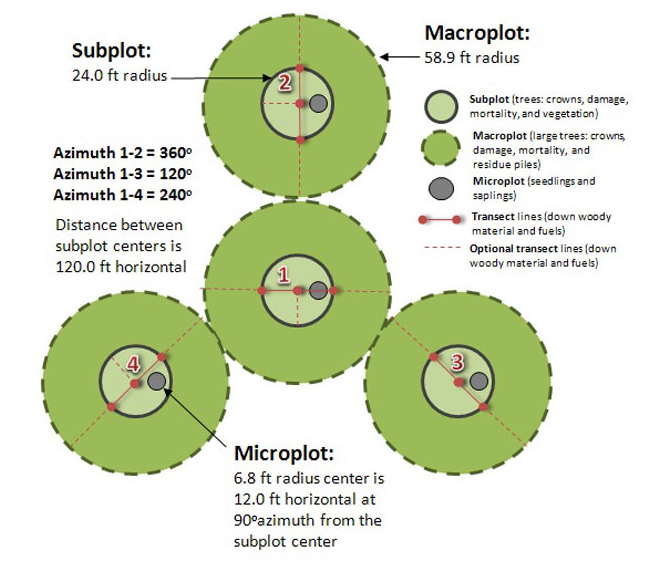

## Let's put spatial coordinates to or plots, subplots, and trees
Create a definition to iteratively add subplots and trees to a polygon geodataframe and point geoseries.
What does get_geos_trees return?


In [ ]:
dist=120/3.281 #convert distance from feet to meters
prad=24/3.281 #convert plot radius from feet to meters

def get_geos_trees(dbfplot,dbftree,dist,prad):
  '''
    Returns a geodataframe of the plot and tree locations for the specified dataframe

    dbfplot = (dataframe) dataframe of plot data
    dfbtree = (dataframe) dataframe of tree data
    dist = (float) distance from plot center to tree location in meters
    prad = (float) plot radius in meters

    returns a geodataframes of subplot and tree locations
  '''
  plt_lst=[]
  trees_lst=[]
  for rw in dbfplot.to_crs('EPSG:5070').itertuples():
      g=rw.geometry
      cn=rw.CN
      xc=g.x
      yc=g.y

      x1=xc+np.sin(np.radians(360))*dist
      y1=yc+np.cos(np.radians(360))*dist

      x2=xc+np.sin(np.radians(120))*dist
      y2=yc+np.cos(np.radians(120))*dist

      x3=xc+np.sin(np.radians(240))*dist
      y3=yc+np.cos(np.radians(240))*dist

      f_plt=gpd.GeoSeries.from_xy([xc,x1,x2,x3],[yc,y1,y2,y3],crs='EPSG:5070')
      f_plt_buf=f_plt.buffer(prad).to_crs('EPSG:4326') #reproject ot geographic coordinates for plotting in folium
      plt=gpd.GeoDataFrame({'CN':cn,'SPLT':[1,2,3,4]},geometry=f_plt_buf)
      plt_lst.append(plt.to_crs('EPSG:4326'))
      t2t=(dbftree[dbftree.PLT_CN.astype('string')==cn]).copy() #select only trees that are associated with the selected plot
      if t2t.shape[0]>0:
          t2t.loc[:, 'azm'] = np.random.rand(t2t.shape[0]) * 360  # create a random azmith for each tree
          t2t.loc[:, 'dst'] = np.random.rand(t2t.shape[0]) * prad  # create a random distance for each tree
          t2t=t2t[(t2t.TPA_UNADJ<7) & (t2t.TPA_UNADJ>6)] #expansion factor is being used to identify subplot trees
          t2t.loc[:,'tx']=t2t.dst*np.sin(np.radians(t2t.azm)) #calculate the x coordinate of the tree based on the azimuth and distance
          t2t.loc[:,'ty']=t2t.dst*np.cos(np.radians(t2t.azm)) #calculate the y coordinate of the tree based on the azimuth and distance
          dicx={1:xc,2:x1,3:x2,4:x3}
          dicy={1:yc,2:y1,3:y2,4:y3}
          xsp=t2t.SUBP.map(dicx)
          ysp=t2t.SUBP.map(dicy)
          txs=xsp+t2t.tx
          tys=ysp+t2t.ty
          t_pnt=gpd.GeoSeries.from_xy(txs,tys,crs='EPSG:5070').to_crs('EPSG:4326')
          trees_lst.append(t_pnt)

  return pd.concat(plt_lst), pd.concat(trees_lst)

### Get subplot and tree dataframes for the first 100 plots collected within the last 10 years.

In [ ]:
gdf_plt,gdf_trees=get_geos_trees(plot_gte_2016.iloc[0:100],t2,dist,prad)

### Make an interactive map of those plot/subplot locations with a depiction of live trees greater than 5 inches in DBH.
- What is DBH?
- Are there plots with no trees?
- Across all of Montana, which plot has the largest number of live trees greater than 5 inches DBH ?

In [ ]:
import folium
m=gdf_plt.explore(color='red',name='Plot/Subplot')
m=gdf_trees.explore(color='yellow',m=m,name='Live Trees')
folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Esri Imagery',
        overlay = False,
        control = True
       ).add_to(m)
folium.LayerControl().add_to(m)
m

## Notice the number of zero live tree plots.
- How many plots within the last 10 have zero live trees greater than 5 inches DBH across all of Montana?